In [17]:
#julia version:1.11.6
include("CRD_STA.jl")
using Plots
using LinearAlgebra
using NonlinearEigenproblems
using DelimitedFiles
using ProgressMeter

In [31]:
function BF(N_cheb,Ro,Tw,Mr)
    gamma = 1.4
    sigma = 0.72
    Co = 2 - Ro - Ro^2
    u0,v0,w0,f,q,D,D2,x = baseflow_var(N_cheb,Ro,Co)
    H,T = T_ca(Mr,f,q,w0,gamma,Tw)
    F,G,H,T,rho,z = interp(u0,v0,H,T,x,N_cheb,"sim")
    lam = - (2/3) * T
    kappa = (1/sigma) * T
    return F,G,H,T,rho,x,lam,kappa,D,D2
end
function eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,c,num)
    sigma = 0.72
    gamma = 1.4
    # if Ro == -1
    #    A0,A1,A2 = Spatial_mode_BEK(-F,-G,-H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2)
    # else 
    cof = Spatial_mode_BEK(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,N_cheb,Ro,Co,D,D2)
    A0_raw,A1_raw,A2_raw = assemble_mat(cof :: COF,D,D2,be,omega)
    A0,A1,A2 = boudary_condition(A0_raw,A1_raw,A2_raw,N_cheb)
    # end
    nep = PEP([A0,A1,A2]); 
    eigval,eigvec = iar(nep,σ = c , neigs = num ,maxit = 500,tol=1e-10)
    # eigval = conj(eigval)
    return eigval
end

eigsol (generic function with 1 method)

In [20]:
N_cheb = 199
Ro = -0.5
Tw = 1.0
Mr = 0.3
gamma = 1.4
sigma = 0.72
Co = 2-Ro-Ro^2
be = 0.117
num = 1
omega = 0.0
data = [0 0 0 0 0]
F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Ro,Tw,Mr)
R = 164
Ma = Mr/R
eigval = eigsol(-F,-G,-H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,0.4,num)
# data = vcat(data,[R real(eigval[1]) imag(eigval[1]) real(eigval[end]) imag(eigval[end])])

1-element Vector{ComplexF64}:
 0.4771337631438576 + 0.0007839817254493849im

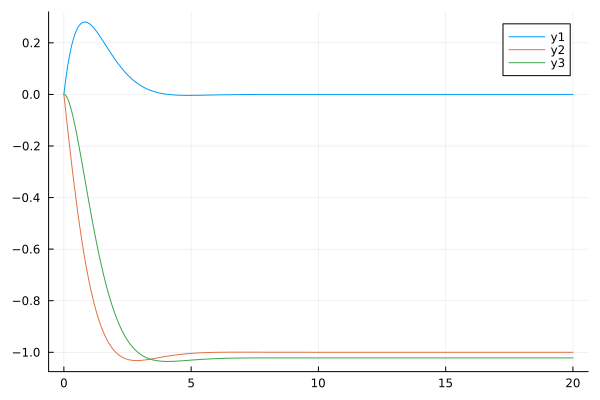

In [9]:
plot(z,F)
plot!(z,G)
plot!(z,H)

In [173]:
data = [0 0 0]
for N_cheb = 49 : 25 : 199
    Ro = -1
    Tw = 1
    Mr = 1.2
    R = 440
    gamma = 1.4
    sigma = 0.72
    Co = 2-Ro-Ro^2
    Ma = Mr/R
    be = 0.038
    num = 1
    omega = 0
    F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Ro,Tw,Mr)
    eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,0.1,num)
    data = vcat(data,[N_cheb real(eigval[1]) imag(eigval[1])])
end

In [32]:
cur1(1.0,0.3,-0.5,0.0,400,0.1,0.05)

InterruptException: InterruptException:

In [29]:
function cur1(Tw,Mr,Ro,OMEGA,R_ini,c_ini,be_ini)
    N_cheb = 199
    gamma = 1.4
    sigma = 0.72
    be_step = -0.0008
    num = 1
    Co = 2-Ro-Ro^2
    omega = OMEGA/R_ini
    Ma = Mr/R_ini
    F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Ro,Tw,Mr)
    initial = []
    tempvec_1 = [0 0 0 0 0 0 0]
    eigval = 0
    writedlm("output.dat",initial)
    writedlm("output_eig.dat",initial)
    eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R_ini,Ma,omega,be_ini,N_cheb,Ro,Co,D,D2,c_ini,num)
    if imag(eigval[1]) < 0
        for be = be_ini : 0.25 * be_step : 0
            eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R_ini,Ma,omega,be_ini,N_cheb,Ro,Co,D,D2,c_ini,num)
            point = filter(x -> abs(imag(x)) < 0.0005 , eigval)
            open("output_eig.dat", "a") do io
                write(io,"be=$be,eig=$eigval\n")
            end
            if !isempty(point)
                initial = [omega R_ini be real(point) imag(point)]
                break
            end
        end
    elseif imag(eigval[1]) > 0
        for be = be_ini : -0.25 * be_step : 0.5
            eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R_ini,Ma,omega,be_ini,N_cheb,Ro,Co,D,D2,c_ini,num)
            point = filter(x ->  - 0.0005 < imag(x) < 0.0005, eigval)
            open("output_eig.dat", "a") do io
                write(io,"be=$be,eig=$eigval\n")
            end
            if !isempty(point)
                initial = [omega R_ini be real(point) imag(point)]
                break
            end
        end
    end
    total = initial

 # CACULATE

    for be = initial[end,3] +  be_step  :  -1 * be_step : 0.4

        num = 1

        c = total[end,4] - im * total[end,5]
        eigval_1 = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,total[end,2],Ma,omega,be+2*be_step,N_cheb,Ro,Co,D,D2,c_ini,num)
        eigval_2 = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,total[end,2],Ma,omega,be-2*be_step,N_cheb,Ro,Co,D,D2,c_ini,num)

        if (imag(eigval_1[1]) < 0 && imag(eigval_2[1]) > 0) || (imag(eigval_1[1]) < 0 && imag(eigval_2[1]) < 0)

            mode = 1

        elseif (imag(eigval_1[1]) > 0 && imag(eigval_2[1]) < 0) || (imag(eigval_1[1]) > 0 && imag(eigval_2[1]) > 0)

            mode = 2

        end
        
        if mode == 1 

            for R = total[end,2] : R_step : 600

                c = total[end,4] - im * total[end,5]
                eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,c,num)
                # index = findmin(abs.(imag(eigval)))
                
                tempvec = [tempvec;[omega R be real(eigval[1]) imag(eigval[1])]]

                len = size(tempvec,1)

                open("output.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if tempvec[end-1, 5] * tempvec[end,5] < 0

                    total = [total ; tempvec[end-1:end-1,:]]
                    tempvec = [0 0 0 0 0]
                    writedlm("ome=$(omega).dat",total)
                    break
                end
                
                if len > 5 && abs(tempvec[end,5]) > abs(tempvec[end-1,5])

                    mode = 2
                    tempvec = [0 0 0 0 0]
                    break
                end
            end
        end


        if mode == 2

            for R = total[end,2]: -R_step : 0

                c = total[end,4] - im * total[end,5]
                eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,c,num)
                # index = findmin(abs.(imag(eigval)))
                
                tempvec = [tempvec;[omega R be real(eigval[1]) imag(eigval[1])]]

                len = size(tempvec,1)

                open("output.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if tempvec[end-1, 5] * tempvec[end,5] < 0

                    total = [total ; tempvec[end-1:end-1,:]]
                    tempvec = [0 0 0 0 0]
                    writedlm("ome=$(omega).dat",total)
   
                    break
                end
                
                if len > 5 && abs(tempvec[end,5]) > abs(tempvec[end-1,5])

                    mode = 1
                    tempvec = [0 0 0 0 0]
                    break
                end
            end            
        end

        if mode == 1
            
            for R = total[end,2]: R_step : 600

                if total[end,3] == be

                    break

                end 

                c = total[end,4] - im * total[end,5]
                eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,c,num)
                # index = findmin(abs.(imag(eigval)))
                
                tempvec = [tempvec;[omega R be real(eigval[1]) imag(eigval[1])]]

                len = size(tempvec,1)

                open("output.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if tempvec[end-1, 5] * tempvec[end,5] < 0

                    total = [total ; tempvec[end-1:end-1,:]]
                    tempvec = [0 0 0 0 0]
                    writedlm("ome=$(omega).dat",total)
   
                    break
                end
                
                if len > 5 && abs(tempvec[end,5]) > abs(tempvec[end-1,5])

                    mode = 2
                    tempvec = [0 0 0 0 0]
                    break
                end
            end        
        end

        if total[end,2] > R_ini + 10 && size(total,1)>40
            break
        end
    end
 end

cur1 (generic function with 1 method)

In [ ]:

function cur(Tw,Mr,Ro,OMEGA,R_ini,c_ini,be_ini)

    N_cheb = 199
    gamma = 1.4
    sigma = 0.72
    be_step = -0.0005
    num = 1
    Co = 2-Ro-Ro^2
    omega = OMEGA/R_ini
    Ma = Mr/R_ini
    F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Ro,Tw,Mr)
    initial = []
    tempvec_1 = [0 0 0 0 0 0 0]
    eigval = 0
    writedlm("output.dat",initial)
    writedlm("output_eig.dat",initial)
    eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R_ini,Ma,omega,be_ini,N_cheb,Ro,Co,D,D2,c_ini,num)
    if imag(eigval[1]) < 0
        for be = be_ini :  be_step : -0.5
            sig_last = sign(imag(eigval[1]))
            eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R_ini,Ma,omega,be,N_cheb,Ro,Co,D,D2,c_ini,num)
            sig_now = sign(imag(eigval[1]))
            # point = filter(x -> abs(imag(x)) < 0.0004 , eigval)
            open("output_eig.dat", "a") do io
                write(io,"be=$be,eig=$eigval\n")
            end
            if sig_last * sig_now < 0 && sig_last != 0 
                initial = [omega R_ini be real(eigval[1]) imag(eigval[1]) real(eigval[end]) imag(eigval[end])]
                break
            end
        end
    elseif imag(eigval[1]) > 0
        for be = be_ini : - be_step : 0.5
            sig_last = sign(imag(eigval[1]))
            eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R_ini,Ma,omega,be,N_cheb,Ro,Co,D,D2,c_ini,num)
            sig_now = sign(imag(eigval[1]))
            open("output_eig.dat", "a") do io
                write(io,"be=$be,eig=$eigval\n")
            end
            if sig_last * sig_now < 0 && sig_last != 0
                initial = [omega R_ini be real(eigval[1]) imag(eigval[1]) real(eigval[end]) imag(eigval[end])]
                break
            end
        end
    end
    total = initial
    be = initial[3] - be_step
    dir = 0
    boundlen = 5
 # CACULATE

    while true
        index = findall(x->x==findmin([total[end,5],total[end,7]])[1],total[end,:])
        c = total[end,index[1] - 1]
        eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,total[end,2],Ma,omega,be,N_cheb,Ro,Co,D,D2,c,num)
        eigval_1 = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,total[end,2],Ma,omega,be - 0.0001,N_cheb,Ro,Co,D,D2,c,num)
        eigval_2 = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,total[end,2],Ma,omega,be + 0.0001 * be_step,N_cheb,Ro,Co,D,D2,c,num)
        index1 = findmin(x-> (imag(x)) , eigval_1)[2]
        index2 = findmin(x-> (imag(x)) , eigval_2)[2]
        if 0.13<findmax(real,eigval)[1]<0.3
            num = 2
        else 
            num = 1
        end
        if size(total,1) > 3 && abs(total[end,2] - total[end-1,2]) <=2
            R_step = 0.25
        else
            R_step = 1
        end
        if (imag(eigval_1[index1]) < 0 && imag(eigval_2[index2]) > 0) || (imag(eigval_1[index1]) > 0 && imag(eigval_2[index2]) > 0) || dir == -1
            mode = 1
        elseif (imag(eigval_1[index1]) > 0 && imag(eigval_2[index2]) < 0) || (imag(eigval_1[index1]) < 0 && imag(eigval_2[index2]) < 0)
            mode = 2
        end
        
        if mode == 1 

            for R = total[end,2] : R_step : 700

                Ma = Mr/R
                omega = OMEGA/R
                eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,c,num)
                index = findmin((imag),eigval)[2]

                tempvec_1 = [tempvec_1;[omega R be real(eigval[1]) imag(eigval[1]) real(eigval[end] ) imag(eigval[end])]]     
                len = size(tempvec_1,1)
                if imag(eigval[index]) > 0
                    boundlen = 10
                else
                    boundlen = 60
                end
                open("output.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if ((tempvec_1[end-1, 5] * tempvec_1[end,5]) < 0 && abs(tempvec_1[end,5] < 0.001)) || (abs(tempvec_1[end,5])<3e-5) || ((tempvec_1[end-1, 7] * tempvec_1[end,7]) < 0) || (abs(tempvec_1[end,7])<3e-5) 

                    total = [total ; tempvec_1[end:end,:]]
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end

                if (len > boundlen && abs(tempvec_1[end,5]) > abs(tempvec_1[end-1,5])) || len > 100

                    mode = 2
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end
            end        
        end


        if mode == 2

            for R = total[end,2]: -R_step : 0

                Ma = Mr/R
                omega = OMEGA/R
                eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,c,num)
                index = findmin((imag),eigval)[2]
                tempvec_1 = [tempvec_1;[omega R be real(eigval[1]) imag(eigval[1]) real(eigval[end] ) imag(eigval[end])]]     
                len = size(tempvec_1,1)
                if imag(eigval[index]) > 0
                    boundlen = 10
                else
                    boundlen = 60
                end
                open("output.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end
                if ((tempvec_1[end-1, 5] * tempvec_1[end,5]) < 0 && abs(tempvec_1[end,5] < 0.001)) || (abs(tempvec_1[end,5])<3e-5) || ((tempvec_1[end-1, 7] * tempvec_1[end,7]) < 0) || (abs(tempvec_1[end,7])<3e-5) 

                    total = [total ; tempvec_1[end:end,:]]
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end
                
                if (len > boundlen && abs(tempvec_1[end,5]) > abs(tempvec_1[end-1,5])) || len > 100

                    mode = 1
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end
            end        
        end

        if mode == 1

            for R = total[end,2]: R_step : 700
                Ma = Mr/R
                omega = OMEGA/R
                if total[end,3] == be

                    break

                end 
                
                eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R,Ma,omega,be,N_cheb,Ro,Co,D,D2,c,num)
                index = findmin((imag),eigval)[2]
                tempvec_1 = [tempvec_1;[omega R be real(eigval[1]) imag(eigval[1]) real(eigval[end] ) imag(eigval[end])]]     

                len = size(tempvec_1,1)
                if imag(eigval[index]) > 0
                    boundlen = 10
                else
                    boundlen = 60
                end
                open("output.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if ((tempvec_1[end-1, 5] * tempvec_1[end,5]) < 0 && abs(tempvec_1[end,5] < 0.001)) || (abs(tempvec_1[end,5])<3e-5) || ((tempvec_1[end-1, 7] * tempvec_1[end,7]) < 0) || (abs(tempvec_1[end,7])<3e-5) 

                    total = [total ; tempvec_1[end:end,:]]
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end
                
                if (len > boundlen && abs(tempvec_1[end,5]) > abs(tempvec_1[end-1,5])) || len > 100

                    mode = 2
                    tempvec_1 = [0 0 0 0 0 0 0]

                    break
                end
            end        
        end
        c = total[end,4]
        Ma = Mr/total[end,2]
        eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,total[end,2]+2,Ma,omega,be,N_cheb,Ro,Co,D,D2,c,num)
        sig = findmin(imag,eigval)[1]
        if size(total,1) > 10 &&total[end,3] != be 
            dir = -1 
            be_step = 0.0009
        else
            if sig > 0
                dir = -1
                be_step = 0.00075
            else
                dir = 1
                be_step = 0.00075
            end
        end
            be += dir * be_step
        filename = "ome=$(omega)_Tw=$(Tw)_Mr=$(Mr)_temp.dat"
        str1 = "Variables=\"omega\" \"R\" \"beta\" \"alpha_r_1\" \"alpha_i_1\" \"alpha_r_2\" \"alpha_i_2\""
        str2 = "Zone T=\"omega=$(omega),Ma=$(Mr),Tw=$(Tw),Ro=$(Ro)\""
        open(filename,"w") do io
            println(io,str1)
            println(io,str2)
            writedlm(io,total[2:end,:])
        end
        if total[end,2] > 400 && size(total,1) > 30 && total[end,4] > 0.4
            break
        end
        # app = readdlm("ome=$(omega)_Tw=$(Tw)_Mr=$(Mr)_temp.dat")
        # ori = readdlm("ome=$(omega)_Tw=$(Tw)_Mr=$(Mr).dat")
        # if app[end,2] < ori[3,2]
        #     break
        # end
    end
end

cur (generic function with 1 method)

In [15]:
all = [0 0 0 0]
R_ini = 600
c_ini = 0.05
be_ini = 0.03
Ro = -1
for omega in 0.0 : 0.002 : 0.01
    for Tw in 1.0 
        for Mr in 0.3
            N_cheb = 199
            gamma = 1.4
            sigma = 0.72
            be_step = -0.0002
            num = 1
            Co = 2-Ro-Ro^2
            Ma = Mr/R_ini
            F,G,H,T,rho,z,lam,kappa,D,D2 = BF(N_cheb,Ro,Tw,Mr)
            initial = []
            tempvec_1 = [0 0 0 0 0 0 0]
            eigval = 0
            writedlm("output.dat",initial)
            writedlm("output_eig.dat",initial)
            eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R_ini,Ma,omega,be_ini,N_cheb,Ro,Co,D,D2,c_ini,num)
            if imag(eigval[1]) < 0
                for be = be_ini :  be_step : -0.5
                    sig_last = sign(imag(eigval[1]))
                    eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R_ini,Ma,omega,be,N_cheb,Ro,Co,D,D2,c_ini,num)
                    sig_now = sign(imag(eigval[1]))
                    # point = filter(x -> abs(imag(x)) < 0.0004 , eigval)
                    open("output_eig.dat", "a") do io
                        write(io,"be=$be,eig=$eigval\n")
                    end
                    if sig_last * sig_now < 0 && sig_last != 0 
                        initial = [omega Tw Mr be ]
                        break
                    end
                end
            elseif imag(eigval[1]) > 0
                for be = be_ini : - be_step : 0.5
                    sig_last = sign(imag(eigval[1]))
                    eigval = eigsol(F,G,H,rho,lam,kappa,T,sigma,gamma,R_ini,Ma,omega,be,N_cheb,Ro,Co,D,D2,c_ini,num)
                    sig_now = sign(imag(eigval[1]))
                    open("output_eig.dat", "a") do io
                        write(io,"be=$be,eig=$eigval\n")
                    end
                    if sig_last * sig_now < 0 && sig_last != 0
                        initial = [omega Tw Mr be ]
                        break
                    end
                end
            end
            all = [all;initial]
            writedlm("test.dat",all)
        end
    end
end

InterruptException: InterruptException:

In [4]:
for omega in 0.008
    for Tw in 1.4
        for Mr in 0.3
            R_ini = 500
            c_ini = 0.05
            be_ini = 0.01
            Ro = -1
            cur(Tw,Mr,Ro,omega,R_ini,c_ini,be_ini)
        end
    end
end

/home/zhj/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/YE7xF/src/integrator_interface.jl:665
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/YE7xF/src/integrator_interface.jl:665
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/YE7xF/src/integrator_interface.jl:665
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/YE7xF/src/integrator_interface.jl:665
┌ Warning: Instability detected. Aborting
└ @ SciMLBase /home/zhj/.julia/packages/SciMLBase/YE7xF/src/integr

InterruptException: InterruptException:

In [35]:
for omega = -0.025
    for Mr = 0.3 : 0.3 : 1.2
        for Tw = 0.8 : 0.1 : 1.2
            ori = readdlm("omega=$(omega)/ome=$(omega)_Tw=$(Tw)_Mr=$(Mr).dat")
            all = [ori[1:260,:];ori[263:end,:]]
            writedlm("omega=$(omega)/ome=$(omega)_Tw=$(Tw)_Mr=$(Mr).dat",all)
        end
    end
end

In [355]:
a = [1,4,5,2,1]
num = sum(x->x==10,a)

0

In [480]:
Ro = -1
for omega = 0
    for Mr = 0.3 : 0.3 : 1.2
        for Tw = 0.8 : 0.1 : 1.2
            
            str1 = "Zone T= \"omega=$(omega),Ma=$Mr,Tw=$Tw,INTER\" "
            str2 = "Variables=\"R\" \"beta\" "
            str3 = "Variables=\"omega\" \"R\" \"beta\" \"omega_r\" \"omega_i\" "
            str4 = "Zone T= \"omega=$(omega),Ma=$Mr,Tw=$Tw,ORIG\" "
            read_path = joinpath("ome=$(omega)_Tw=$(Tw)_Mr=$(Mr).dat")
            file_parh = joinpath("ome=$(omega)_Tw=$(Tw)_Mr=$(Mr)_interp.dat")
            a0 = readdlm(read_path)
            a1 =  Matrix{Float32}(a0[3:end,:])
            k = 2      
            p = sortperm(a1[:, k])
            a1 = a1[p, :]  
            x = a1[:,3]
            y = a1[:,2] 
            function sort_unique_xy(x::AbstractVector, y::AbstractVector)
                @assert length(x) == length(y) "x,y 长度不一致"
                p = sortperm(x)
                xs, ys = x[p], y[p]
                # 去掉重复 x（保留第一次出现）
                keep = [true; diff(xs) .> 0]
                return xs[keep], ys[keep]
            end
            xs, ys = sort_unique_xy(x, y)
            xq = range(xs[1], xs[end], length=500)
            yq_quad = pchip_interp_extrap(xs, ys, collect(xq); m=5, mode=:quad)
            function smooth_moving_avg(y; w)
                @assert isodd(w) "窗口 w 请设为奇数"
                r = (w-1)÷2
                ys = similar(y, Float64)
                for i in eachindex(y)
                    lo = max(firstindex(y), i-r)
                    hi = min(lastindex(y),  i+r)
                    ys[i] = Statistics.mean(@view y[lo:hi])
                end
                return ys
            end
            y_ma = smooth_moving_avg(yq_quad; w= eleven=13)  # 写法示例：w=11
            all = [y_ma xq]  
            open(file_parh,"w") do f
                println(f, str2)
                println(f, str1)
                writedlm(f, all)
            end
        end
    end
end

In [476]:
# ——— 高精度一维插值 + 外推（已修正，无“2h”“3s[1]”之类语法错误） ———
# 依赖：仅 Base/LinearAlgebra
using LinearAlgebra

# 计算 PCHIP 端点与内点斜率（Fritsch–Carlson + Fritsch–Butland 端点处理）
function _pchip_slopes(x::AbstractVector{<:Real}, y::AbstractVector{<:Real})
    n = length(x)
    @assert n == length(y) ≥ 2 "x,y 长度需一致且≥2"
    @assert issorted(x) "x 必须升序"

    h = @views x[2:end] .- x[1:end-1]                 # 段长
    s = @views (y[2:end] .- y[1:end-1]) ./ h          # 分段斜率 Δy/Δx

    d = Vector{Float64}(undef, n)

    # n == 2 时只有一段：两端导数都等于该段斜率
    if n == 2
        d[1] = s[1]; d[2] = s[1]
        return d
    end

    # 端点导数（Fritsch–Butland 建议），然后做单调性限制
    d[1] = ((2*h[1] + h[2]) * s[1] - h[1] * s[2]) / (h[1] + h[2])
    if sign(d[1]) != sign(s[1])
        d[1] = 0.0
    elseif sign(s[1]) != sign(s[2]) && abs(d[1]) > 3 * abs(s[1])
        d[1] = 3 * s[1]
    end

    d[n] = ((2*h[end] + h[end-1]) * s[end] - h[end] * s[end-1]) / (h[end] + h[end-1])
    if sign(d[n]) != sign(s[end])
        d[n] = 0.0
    elseif sign(s[end]) != sign(s[end-1]) && abs(d[n]) > 3 * abs(s[end])
        d[n] = 3 * s[end]
    end

    # 内点导数（Fritsch–Carlson 加权调和平均，保形避免振荡）
    @inbounds for i in 2:n-1
        if s[i-1] == 0 || s[i] == 0 || sign(s[i-1]) != sign(s[i])
            d[i] = 0.0
        else
            w1 = 2*h[i] + h[i-1]
            w2 = h[i] + 2*h[i-1]
            d[i] = (w1 + w2) / (w1 / s[i-1] + w2 / s[i])
        end
    end

    return d
end

# Hermite 段值
@inline function _hermite(x0, x1, y0, y1, m0, m1, x)
    t  = (x - x0) / (x1 - x0)
    t2 = t * t
    t3 = t2 * t
    h00 =  2*t3 - 3*t2 + 1
    h10 =      t3 - 2*t2 + t
    h01 = -2*t3 + 3*t2
    h11 =      t3 -   t2
    return h00*y0 + h10*(x1 - x0)*m0 + h01*y1 + h11*(x1 - x0)*m1
end

# 端点附近 m 个点的二次最小二乘外推（m≥3 自动夹取）
function _quad_extrap_edge(x::AbstractVector{<:Real}, y::AbstractVector{<:Real},
                           xq::Real; left::Bool, m::Int=4)
    n  = length(x)
    @assert n == length(y) ≥ 3 "二次外推建议≥3点"
    mm = max(3, min(m, n))                         # 至少3点
    xx = left ? @view(x[1:mm]) : @view(x[end-mm+1:end])
    yy = left ? @view(y[1:mm]) : @view(y[end-mm+1:end])

    # Vandermonde 最小二乘：y ≈ a + b x + c x^2
    A = ones(length(xx), 3)
    @views A[:, 2] .= xx
    @views A[:, 3] .= xx .^ 2
    a, b, c = A \ yy
    return a + b * xq + c * xq^2
end

"""
    pchip_interp_extrap(xs, ys, xq; m=4, mode=:quad)

区间内：PCHIP（三次 Hermite，形状保持）。
区间外：
- mode = :quad → 端点附近 m 点二次拟合外推（精度更高）
- mode = :line → 用 PCHIP 端点导数线性外推（更稳更保形）

支持标量或向量 xq。
"""
function pchip_interp_extrap(xs::AbstractVector{<:Real},
                             ys::AbstractVector{<:Real},
                             xq::Union{Real,AbstractVector{<:Real}}; m::Int=4, mode::Symbol=:quad)
    @assert issorted(xs) "xs 必须升序"
    @assert length(xs) == length(ys) ≥ 2

    d = _pchip_slopes(xs, ys)

    # 标量查询
    if xq isa Real
        if xq ≤ xs[1]
            return (mode === :line) ? (ys[1] + d[1] * (xq - xs[1])) :
                                      _quad_extrap_edge(xs, ys, xq; left=true, m=m)
        elseif xq ≥ xs[end]
            return (mode === :line) ? (ys[end] + d[end] * (xq - xs[end])) :
                                      _quad_extrap_edge(xs, ys, xq; left=false, m=m)
        else
            i = searchsortedlast(xs, xq)   # xs[i] ≤ xq < xs[i+1]
            return _hermite(xs[i], xs[i+1], ys[i], ys[i+1], d[i], d[i+1], xq)
        end
    end

    # 向量查询
    xqv = xq
    yq  = similar(xqv, Float64)
    @inbounds for j in eachindex(xqv)
        xqi = xqv[j]
        if xqi ≤ xs[1]
            yq[j] = (mode === :line) ? (ys[1] + d[1] * (xqi - xs[1])) :
                                       _quad_extrap_edge(xs, ys, xqi; left=true, m=m)
        elseif xqi ≥ xs[end]
            yq[j] = (mode === :line) ? (ys[end] + d[end] * (xqi - xs[end])) :
                                       _quad_extrap_edge(xs, ys, xqi; left=false, m=m)
        else
            i = searchsortedlast(xs, xqi)
            yq[j] = _hermite(xs[i], xs[i+1], ys[i], ys[i+1], d[i], d[i+1], xqi)
        end
    end
    return yq
end


pchip_interp_extrap